In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,  StandardScaler
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_samples
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, cdist,squareform
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

<bound method NDFrame.head of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

Количество пропусков по каждому признаку
CustomerID                0

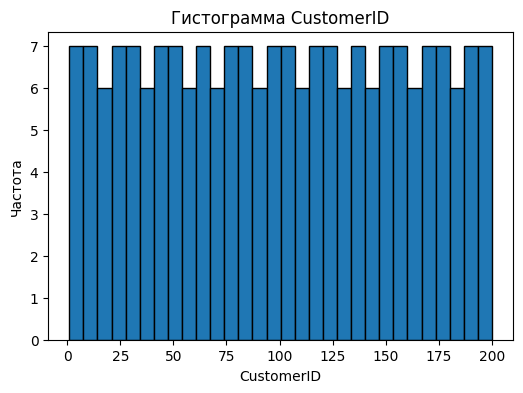

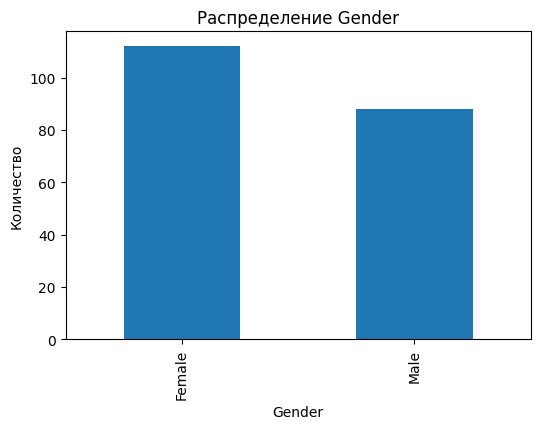

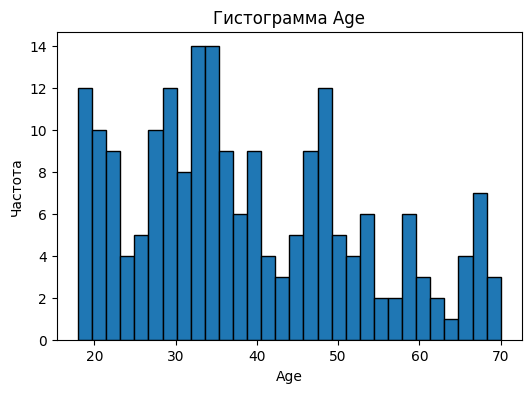

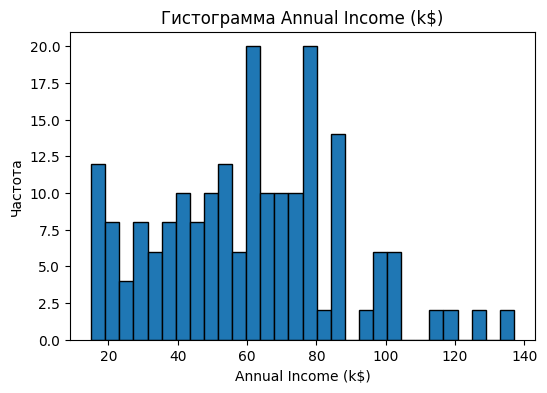

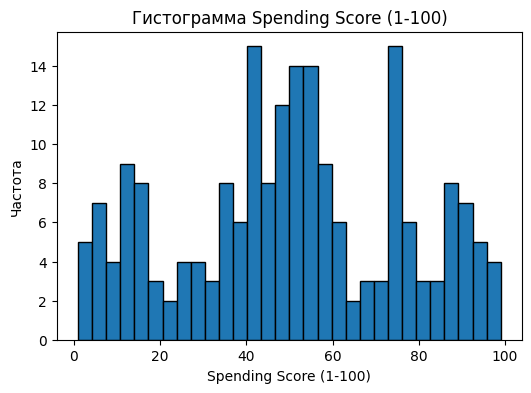

In [3]:
df = pd.read_csv('RGR.csv')
print(df.head)
print("\nКоличество пропусков по каждому признаку")
print(df.isnull().sum())

for col in df.columns:
    plt.figure(figsize=(6,4))

    if df[col].dtype == "object" or df[col].nunique() <= 4:  
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Распределение {col}")
        plt.xlabel(col)
        plt.ylabel("Количество")
    else:  
        df[col].plot(kind="hist", bins=30, edgecolor="black")
        plt.title(f"Гистограмма {col}")
        plt.xlabel(col)
        plt.ylabel("Частота")
    
    plt.show()

In [4]:
print("Распределение классов Gender:")
print(df["Gender"].value_counts())
print("\n")

numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

print("Статистика по числовым признакам:\n")

for col in numeric_cols:
    print(f"Признак: {col}")
    print("  Минимум:", df[col].min())
    print("  Максимум:", df[col].max())
    print("  Среднее:", df[col].mean())
    print("  Медиана:", df[col].median())
    print("  Дисперсия:", df[col].var())
    print("  Стандартное отклонение:", df[col].std())
    print("  Эксцесс:", df[col].kurt())
    print()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"  Количество выбросов: {len(outliers)}")
    print(f"  Порог нижний: {lower}, верхний: {upper}")
    print()

Распределение классов Gender:
Gender
Female    112
Male       88
Name: count, dtype: int64


Статистика по числовым признакам:

Признак: Age
  Минимум: 18
  Максимум: 70
  Среднее: 38.85
  Медиана: 36.0
  Дисперсия: 195.13316582914572
  Стандартное отклонение: 13.96900733155888
  Эксцесс: -0.6715728615981695

  Количество выбросов: 0
  Порог нижний: -1.625, верхний: 79.375

Признак: Annual Income (k$)
  Минимум: 15
  Максимум: 137
  Среднее: 60.56
  Медиана: 61.5
  Дисперсия: 689.8355778894472
  Стандартное отклонение: 26.264721165271244
  Эксцесс: -0.09848708652696203

  Количество выбросов: 2
  Порог нижний: -13.25, верхний: 132.75

Признак: Spending Score (1-100)
  Минимум: 1
  Максимум: 99
  Среднее: 50.2
  Медиана: 50.0
  Дисперсия: 666.8542713567839
  Стандартное отклонение: 25.823521668370173
  Эксцесс: -0.8266291062061502

  Количество выбросов: 0
  Порог нижний: -22.625, верхний: 130.375



В нашем наборе данных есть следующие числовые признаки:CustomerID (не информативный, служебный), Age, Annual Income, Spending Score; а также категориальный признак Gender.
Выше приведены гистограммы, а также распределение для признака Gender. Все гистограммы не согласуются с нормальным распределением.
Выше мы вывели основные показатели для каждого признака. Исходя из них, мы подтвердили, что признаки не согласуются с нормальным распределением.

Возраст респондентов варьируется от 18 до 70 лет, при среднем значении 38,85 и медиане 36 лет, что указывает на незначительную правостороннюю асимметрию. Стандартное отклонение примерно 14 лет. Годовой доход изменяется в диапазоне от 15 до 137 тыс. долларов, среднее значение составляет 60,56 тыс., медиана — 61,5 тыс., что указывает на близость распределения к симметричному. Стандартное отклонение равно 26,26 тыс., что отражает значительную вариативность доходов. Значения индекса лежат в интервале от 1 до 99, при среднем 50,2 и медиане 50, что свидетельствует о симметричном распределении. Стандартное отклонение (≈25,8) указывает на высокую степень разброса.

Также мы проверили пропуски, их не наблюдается на всем датасете.

Анализ исходных данных показывает, что условия для применения методов кластеризации в целом выполнены. В наборе данных отсутствует целевая переменная или заранее заданные классы, что соответствует задаче обучения без учителя и делает кластеризацию методологически корректной. Используемые признаки (возраст, годовой доход и индекс потребительских расходов) имеют ясную интерпретацию и экономический смысл, а их совместное использование позволяет формировать содержательные и интерпретируемые кластеры потребителей.

In [5]:
for col in numeric_cols:
    median_value = df[col].median()
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median_value

C:\Users\manui\AppData\Local\Temp\ipykernel_20556\2761252560.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '61.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df[col] < lower) | (df[col] > upper), col] = median_value


Избавляемся от выбросов. Значения выбросов были заменены на медианные значения.

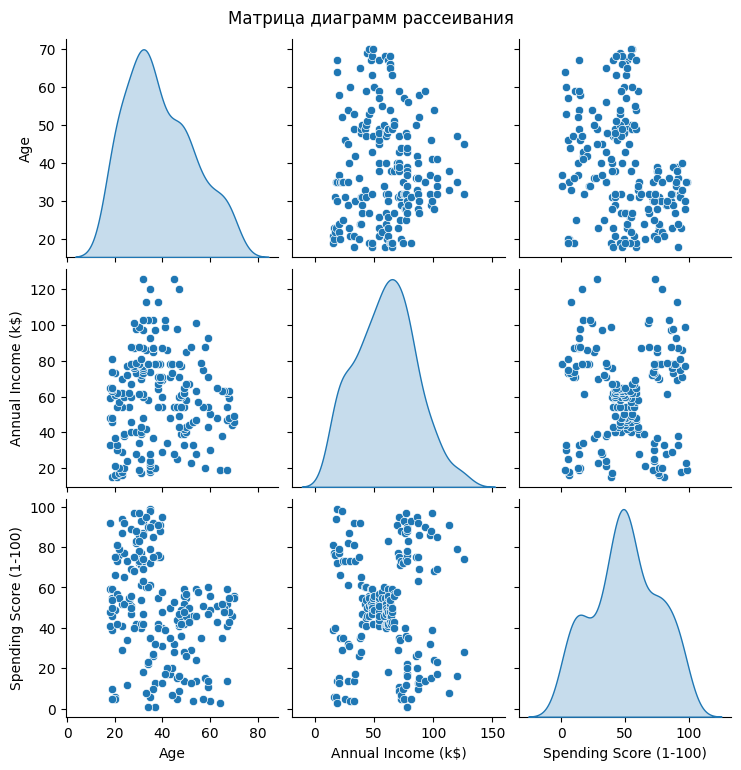

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

sns.pairplot(df[numeric_cols], diag_kind="kde")
plt.suptitle("Матрица диаграмм рассеивания", y=1.02)
plt.show()

Теперь мы стандартизировали числовые признаки при помощи StandardScaler. Он преобразует данные таким образом, что каждый признак имеет нулевое среднее значение и единичное стандартное отклонение. Это позволяет обеспечить сопоставимый вклад всех признаков при вычислении расстояний между объектами, что особенно важно для методов кластеризации, основанных на метриках расстояния.

Также построили матрицу диаграмм рассеивания. Исходя из полученной матрицы, можно предположить, что количество кластеров 5, их структура нелинейная. Можно предположить, что их структура скорее всего сферическая или эллипсоидная.

Выявленные особенности структуры данных обосновывают применение методов кластерного анализа. Метод k-средних целесообразен в данной задаче, поскольку визуально наблюдаемые группы характеризуются относительной компактностью и могут быть аппроксимированы центрами в пространстве признаков. Иерархический метод отличается принципом формирования групп, основанным на последовательном объединении наиболее близких наблюдений. Это позволяет оценить устойчивость выявленной кластерной структуры и проверить, сохраняются ли основные сегменты при использовании альтернативного алгоритма кластеризации.

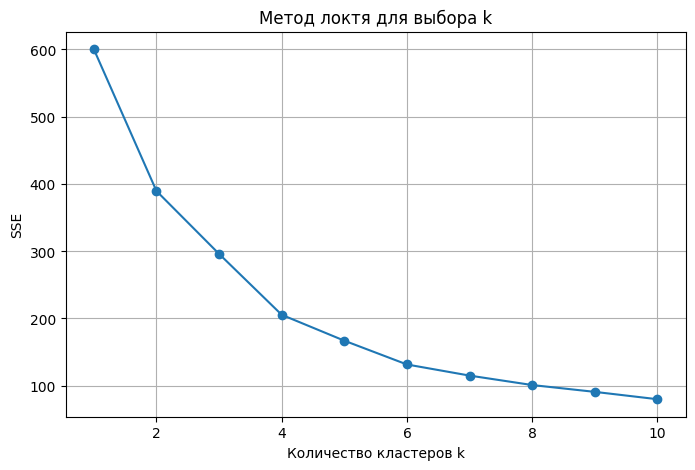

In [7]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Строим график
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Метод локтя для выбора k")
plt.xlabel("Количество кластеров k")
plt.ylabel("SSE")
plt.grid(True)
plt.show()

На графике видно, что достаточно резкого спада не наблюдается, график выглядит очень равномерным. Из-за этого можно предположить, что выбор К в диапазоне от 4 до 7 можно считать уместным. Выберем значение К равное 6. 

In [ ]:
# Выбрано 6 кластеров
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = labels


# Метрики
inertia = kmeans.inertia_  
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

print(f"Число кластеров: {k}")
print(f"Inertia (SSE): {inertia:.2f}")
print(f"Silhouette score: {sil:.4f}")
print(f"Calinski-Harabasz index: {ch:.2f}")
print(f"Davies-Bouldin index: {db:.4f}")


compactness = {}
diameters = {}

for cluster_id in range(k):
    cluster_points = X_scaled[labels == cluster_id]
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_points - center, axis=1)
    compactness[cluster_id] = distances.mean()
    diameters[cluster_id] = distances.max()

rep =0
print("\nCompactness/среднее расстояние до центра:")
for cid, value in compactness.items():
    rep +=value
    print(f"Кластер {cid}: {value:.4f}")
print('comp  = ',rep/k)

s = 0
print("\nДиаметры кластеров:")
for cid, value in diameters.items():
    s+=value
    print(f"Кластер {cid}: {value:.4f}")
print('diamets S = ',s/k)


center_distances = pairwise_distances(kmeans.cluster_centers_)

print("\nРасстояния между центрами кластеров:")
print(center_distances)


sil_samples = silhouette_samples(X_scaled, labels)

cluster_sil = {}
for cluster_id in range(k):
    cluster_sil[cluster_id] = sil_samples[labels == cluster_id].mean()

print("\nSilhouette для каждого кластера:")
for cid, value in cluster_sil.items():
    print(f"Кластер {cid}: {value:.4f}")

Число кластеров: 6
Inertia (SSE): 131.68
Silhouette score: 0.4288
Calinski-Harabasz index: 138.00
Davies-Bouldin index: 0.8209

Compactness/среднее расстояние до центра:
Кластер 0: 0.7023
Кластер 1: 0.6666
Кластер 2: 0.6139
Кластер 3: 0.9378
Кластер 4: 0.6615
Кластер 5: 0.9113
comp  =  0.7489143146113199

Диаметры кластеров:
Кластер 0: 1.1286
Кластер 1: 1.6833
Кластер 2: 1.6124
Кластер 3: 1.6919
Кластер 4: 1.1098
Кластер 5: 1.9478
diamets S =  1.5289745488371793

Расстояния между центрами кластеров:
[[0.         2.44801179 2.76140754 2.09176383 2.10732127 1.78265352]
 [2.44801179 0.         2.43892195 2.61188454 1.74713389 3.49319978]
 [2.76140754 2.43892195 0.         3.58835764 1.67750032 2.69833434]
 [2.09176383 2.61188454 3.58835764 0.         2.00634877 2.41672428]
 [2.10732127 1.74713389 1.67750032 2.00634877 0.         2.13811791]
 [1.78265352 3.49319978 2.69833434 2.41672428 2.13811791 0.        ]]

Silhouette для каждого кластера:
Кластер 0: 0.4859
Кластер 1: 0.5072
Кластер 2:

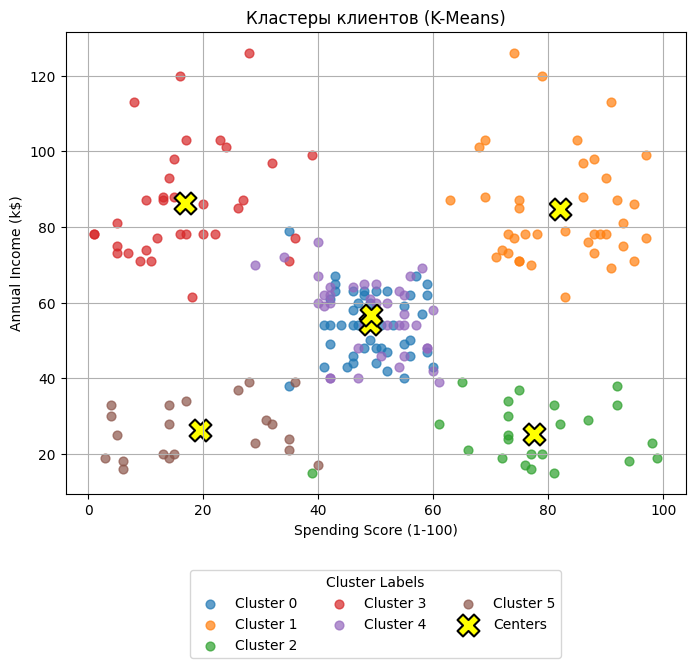

In [ ]:
plt.figure(figsize=(8, 6))

clusters = sorted(df["Cluster"].unique())
colors = plt.cm.tab10(range(len(clusters)))


for cluster_id, color in zip(clusters, colors):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["Spending Score (1-100)"],
        cluster_data["Annual Income (k$)"],
        s=40,
        alpha=0.7,
        color=color,
        label=f"Cluster {cluster_id}"
    )


plt.scatter(
    centers[:, 2],   
    centers[:, 1],   
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    color="yellow",
    label="Centers"
)

plt.xlabel("Spending Score (1-100)")
plt.ylabel("Annual Income (k$)")
plt.title("Кластеры клиентов (K-Means)")
plt.grid(True)


plt.legend(
    title="Cluster Labels",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3  
)

plt.show()

Исходя из полученных метрик: значение силуэта можно считать хорошим; критерий СН показал значение 138, что можно считать хорошим значением, кластеры достаточно хорошо разделены; индекс Davies-Bouldin равен 0,82, кластеры достаточно компактны. Средний коэффициент силуэта равен 0.42, что указывает на умеренно хорошее качество кластеризации: объекты в целом ближе к своему кластеру, чем к соседним. Анализ силуэта по отдельным кластерам показал, что кластеры 1 и 2 обладают наилучшим разделением (значения > 0.50), тогда как кластер 5 характеризуется более слабой структурой.
Анализ средней дистанции объектов до центров кластеров показал, что наиболее компактным является кластер 2, тогда как кластер 3 обладает наибольшей внутрикластерной разрозненностью.
Диаметры кластеров подтверждают данный вывод: кластер 5 имеет наибольший диаметр, что может указывать на его более сложную структуру или наличие подклассов.
Расстояния между центрами кластеров в большинстве случаев превышают внутрикластерные диаметры, что говорит о достаточном разделении кластеров в пространстве признаков.


Теперь реализуем иерархическую кластеризацию. Начнем с вывода дендограммы иерархической кластеризации

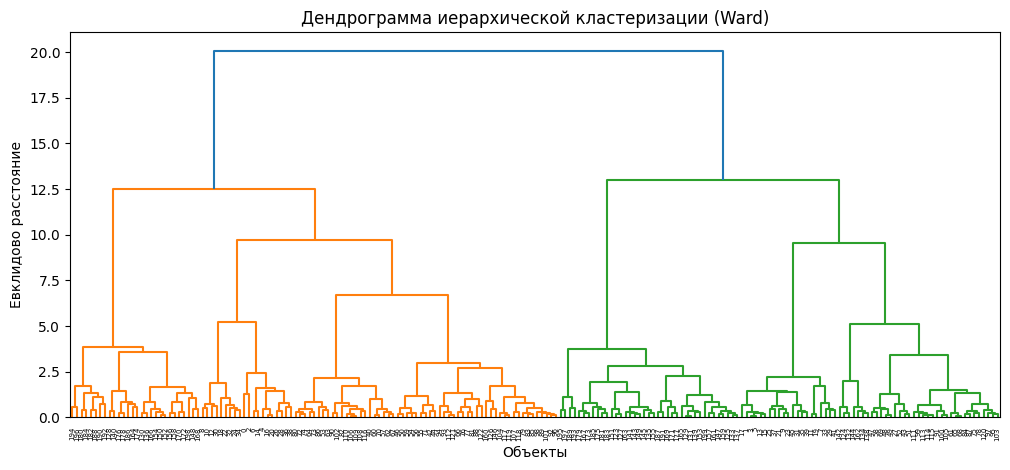

In [10]:
plt.figure(figsize=(12, 5))
Z = linkage(X_scaled, method='ward')

dendrogram(Z)
plt.title("Дендрограмма иерархической кластеризации (Ward)")
plt.xlabel("Объекты")
plt.ylabel("Евклидово расстояние")
plt.show()

Дендрограмма иерархической кластеризации методом Ward демонстрирует наличие двух крупных групп объектов, существенно различающихся между собой. Внутри этих групп наблюдается постепенное объединение объектов без выраженных разрывов по расстоянию, что указывает на размытые границы между кластерами. Выбор числа кластеров k=6  является допустимым.

In [ ]:
k = 6

agg = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

labels_agg = agg.fit_predict(X_scaled)
df["Agg_Cluster"] = labels_agg


# Метрики
sil = silhouette_score(X_scaled, labels_agg)
ch = calinski_harabasz_score(X_scaled, labels_agg)
db = davies_bouldin_score(X_scaled, labels_agg)

cluster_centers = np.array([
    X_scaled[labels_agg == i].mean(axis=0)
    for i in range(k)
])


compactness = {}
diameters = {}

for i in range(k):
    cluster_points = X_scaled[labels_agg == i]
    center = cluster_centers[i]
    distances = np.linalg.norm(cluster_points - center, axis=1)

    compactness[i] = distances.mean()
    diameters[i] = distances.max()


center_distances = pairwise_distances(cluster_centers)
sil_samples = silhouette_samples(X_scaled, labels_agg)

cluster_sil = {}
for i in range(k):
    cluster_sil[i] = sil_samples[labels_agg == i].mean()


print(f"\nИерархическая кластеризация (k={k}):")
print(f"Silhouette score: {sil:.4f}")
print(f"Calinski-Harabasz index: {ch:.2f}")
print(f"Davies-Bouldin index: {db:.4f}")

print("\nCompactness / среднее расстояние до центра:")
for i, val in compactness.items():
    print(f"Кластер {i}: {val:.4f}")

print("\nДиаметры кластеров:")
for i, val in diameters.items():
    print(f"Кластер {i}: {val:.4f}")

print("\nРасстояния между центрами кластеров:")
print(center_distances)

print("\nSilhouette для каждого кластера:")
for i, val in cluster_sil.items():
    print(f"Кластер {i}: {val:.4f}")



Иерархическая кластеризация (k=6):
Silhouette score: 0.4206
Calinski-Harabasz index: 123.74
Davies-Bouldin index: 0.8493

Compactness / среднее расстояние до центра:
Кластер 0: 0.8041
Кластер 1: 0.9870
Кластер 2: 0.6666
Кластер 3: 0.8397
Кластер 4: 0.7464
Кластер 5: 0.5499

Диаметры кластеров:
Кластер 0: 1.5380
Кластер 1: 1.9831
Кластер 2: 1.6833
Кластер 3: 1.5589
Кластер 4: 1.8583
Кластер 5: 1.0655

Расстояния между центрами кластеров:
[[0.         1.7879007  2.29493597 1.91273698 2.07977217 2.66281675]
 [1.7879007  0.         3.52154605 2.56239588 2.17505163 2.7409183 ]
 [2.29493597 3.52154605 0.         2.66972358 1.9126937  2.42294623]
 [1.91273698 2.56239588 2.66972358 0.         2.19085466 3.77945838]
 [2.07977217 2.17505163 1.9126937  2.19085466 0.         1.85952689]
 [2.66281675 2.7409183  2.42294623 3.77945838 1.85952689 0.        ]]

Silhouette для каждого кластера:
Кластер 0: 0.3662
Кластер 1: 0.2861
Кластер 2: 0.5469
Кластер 3: 0.4113
Кластер 4: 0.3502
Кластер 5: 0.5917


Значение коэффициента силуэта, равное 0.42, указывает на умеренно выраженную кластерную структуру: в среднем объекты располагаются ближе к своему кластеру, чем к соседним, однако между отдельными кластерами наблюдается частичное перекрытие. Это свидетельствует о том, что полученное разбиение является приемлемым, но не обладает чётко выраженными границами между всеми кластерами. Индекс Calinski–Harabasz, равный 123, указывает на достаточно хорошее разделение данных на кластеры. Значение индекса Davies–Bouldin, составившее 0.85, характеризует компактность и разделимость кластеров. Поскольку меньшие значения данного индекса соответствуют более качественной кластеризации, полученный результат можно считать положительным и указывающим на то, что в среднем кластеры являются достаточно компактными и различимыми.
В совокупности базовые метрики подтверждают, что иерархическая кластеризация обеспечивает умеренно хорошее качество разбиения данных, при этом структура кластеров не является идеально выраженной.



Анализ средней дистанции объектов до центров кластеров показывает, что наиболее компактным является кластер 5, характеризующийся минимальным средним расстоянием до центра, что свидетельствует о высокой однородности входящих в него объектов. В то же время кластеры 3 и 1 демонстрируют наибольшие значения данного показателя, что указывает на повышенную внутрикластерную разрозненность и более сложную внутреннюю структуру.

Анализ диаметров кластеров подтверждает данный вывод:кластеры 1 и 4 обладают наибольшими диаметрами (порядка 1,9), что может свидетельствовать о значительном разбросе объектов внутри кластеров и потенциальном наличии внутренних подгрупп. Напротив, кластеры 5 и 0 имеют минимальные диаметры, что соответствует их высокой компактности.

Расстояния между центрами кластеров в большинстве случаев превышают средние внутрикластерные расстояния и сопоставимы либо превышают диаметры кластеров, что указывает на достаточно хорошее разделение кластеров в пространстве признаков. В совокупности данные результаты подтверждают, что полученная кластерная структура является интерпретируемой и в целом устойчивой, несмотря на неоднородность компактности отдельных кластеров.


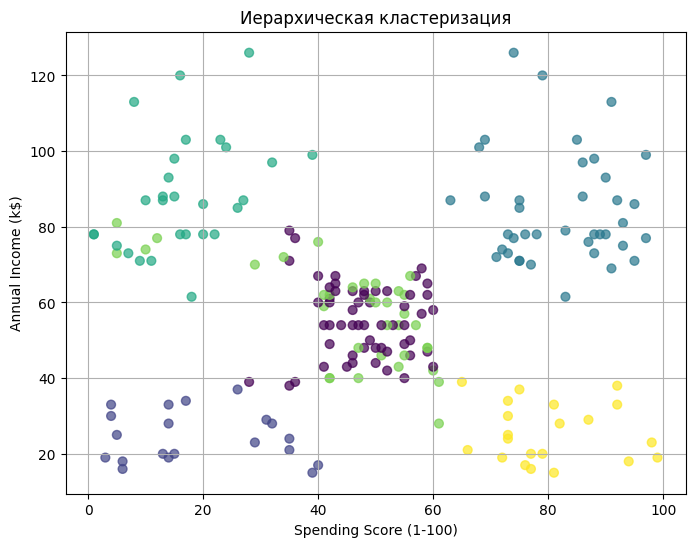

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Spending Score (1-100)"],   # X
    df["Annual Income (k$)"],       # Y
    c=df["Agg_Cluster"],
    s=40,
    alpha=0.7
)

plt.xlabel("Spending Score (1-100)")
plt.ylabel("Annual Income (k$)")
plt.title("Иерархическая кластеризация")
plt.grid(True)
plt.show()

Сравним решения, полученные разными методами.


Метрика	                         К-средних  	Иерархическая кластеризация
Silhouette score	                    0.42	          0.42
Calinski-Harabasz index	              133.87	        127.99
Davies-Bouldin index	                0.8254	          0.85
Compactness (среднее по кластерам)  	0.7512	          0.7605
Диаметры (среднее по кластерам)	        1.7093	          1.68435

Все полученные метрики оказались сопоставимы: значения при разных методах достаточно близки между собой. Можно сделать вывод, что оба решения корректно разделяют данные. При этом метод k-средних демонстрирует незначительное преимущество по индексам Calinski–Harabasz и Davies–Bouldin, что указывает на несколько более компактные и лучше разделённые кластеры. Иерархическая кластеризация, в свою очередь, формирует разбиение схожего качества, подтверждая устойчивость выявленной структуры данных и отсутствие сильной зависимости результатов от выбранного алгоритма.

Теперь посмотрим, как параметры влияют на качество кластеризации. Будем использовать К-средних и К=10.

In [22]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = labels


# Метрики
inertia = kmeans.inertia_  
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

print(f"Число кластеров: {k}")
print(f"Inertia (SSE): {inertia:.2f}")
print(f"Silhouette score: {sil:.4f}")
print(f"Calinski-Harabasz index: {ch:.2f}")
print(f"Davies-Bouldin index: {db:.4f}")


compactness = {}
diameters = {}

for cluster_id in range(k):
    cluster_points = X_scaled[labels == cluster_id]
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_points - center, axis=1)
    compactness[cluster_id] = distances.mean()
    diameters[cluster_id] = distances.max()

rep =0
print("\nCompactness/среднее расстояние до центра:")
for cid, value in compactness.items():
    rep +=value
    print(f"Кластер {cid}: {value:.4f}")
print('comp  = ',rep/k)

s = 0
print("\nДиаметры кластеров:")
for cid, value in diameters.items():
    s+=value
    print(f"Кластер {cid}: {value:.4f}")
print('diamets S = ',s/k)


center_distances = pairwise_distances(kmeans.cluster_centers_)

print("\nРасстояния между центрами кластеров:")
print(center_distances)


sil_samples = silhouette_samples(X_scaled, labels)

cluster_sil = {}
for cluster_id in range(k):
    cluster_sil[cluster_id] = sil_samples[labels == cluster_id].mean()

print("\nSilhouette для каждого кластера:")
for cid, value in cluster_sil.items():
    print(f"Кластер {cid}: {value:.4f}")

Число кластеров: 10
Inertia (SSE): 80.08
Silhouette score: 0.3996
Calinski-Harabasz index: 137.07
Davies-Bouldin index: 0.8755

Compactness/среднее расстояние до центра:
Кластер 0: 0.5925
Кластер 1: 0.5627
Кластер 2: 0.7750
Кластер 3: 0.4990
Кластер 4: 0.4635
Кластер 5: 0.7280
Кластер 6: 0.5717
Кластер 7: 0.7656
Кластер 8: 0.5169
Кластер 9: 0.5636
comp  =  0.6038455798596969

Диаметры кластеров:
Кластер 0: 0.9045
Кластер 1: 0.9432
Кластер 2: 1.5419
Кластер 3: 0.8291
Кластер 4: 0.8356
Кластер 5: 1.2976
Кластер 6: 1.0680
Кластер 7: 1.2966
Кластер 8: 0.8523
Кластер 9: 0.8942
diamets S =  1.0463105501258236

Расстояния между центрами кластеров:
[[0.         2.85073826 2.53185857 3.72105224 1.90380125 1.59584606
  3.35450205 2.86313221 1.86396755 4.44140461]
 [2.85073826 0.         2.44465158 1.61948475 2.87512697 1.72436757
  1.63780788 1.80850101 1.60211126 2.42852504]
 [2.53185857 2.44465158 0.         2.70143209 2.20434939 2.79637024
  3.79436828 1.39061772 1.72190899 2.77154408]
 [3.72

По результатам сравнения метода k-средних при разном числе кластеров можно сделать следующий вывод. Увеличение количества кластеров с 6 до 10 приводит к снижению значения inertia (SSE). Также значение silhouette score уменьшается, что указывает на ухудшение разделимости кластеров и рост перекрытия между ними. Обратную тенденцию демонстрирует индекс Davies–Bouldin, значение которого возрастает при 10 кластерах, что свидетельствует о снижении качества кластерной структуры. 
Хотя показатели компактности и средних диаметров кластеров становятся меньше при 10 кластерах, что указывает на более плотные и мелкие кластеры, это достигается за счёт искусственного дробления данных, а не за счёт формирования более естественной структуры. В целом совокупность метрик показывает, что разбиение на 6 кластеров обеспечивает более сбалансированное соотношение компактности, разделимости и устойчивости кластеров и является более предпочтительным по сравнению с разбиением на 10 кластеров.


Теперь применим метод PCA для того, чтобы оценить значимость признаков.

In [13]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "EVR": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
})

print(explained_variance.head())

feature_names = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print("\n",loadings)



    PC       EVR  Cumulative
0  PC1  0.442427    0.442427
1  PC2  0.333415    0.775842
2  PC3  0.224158    1.000000

                              PC1       PC2       PC3
Age                    -0.706909  0.030555  0.706645
Annual Income (k$)      0.012954  0.999458 -0.030258
Spending Score (1-100)  0.707186  0.012235  0.706921


Таким образом, мы получаем, что первая компонента объясняет примерно 0,44 дисперсии, вторая – 0,33, а третья – 0,22. При анализе влияния признаков на компоненты мы видим следующее:
• Вторая компонента почти целиком описывается признаком Annual Income (k$).
• Влияние признаков Age, Spending Score на третью компоненту можно считать одинаковым. Отражает совместное изменение возраста и потребительской активности.
• Влияние признака Age на первую компоненту примерно 0,71, в то время как влияние признака Spending Score на первую компоненту такое же, но с противоположным знаком. Можно предположить, что чем старше потребители, тем ниже их активность. И наоборот: чем моложе покупатели, тем выше их активность.


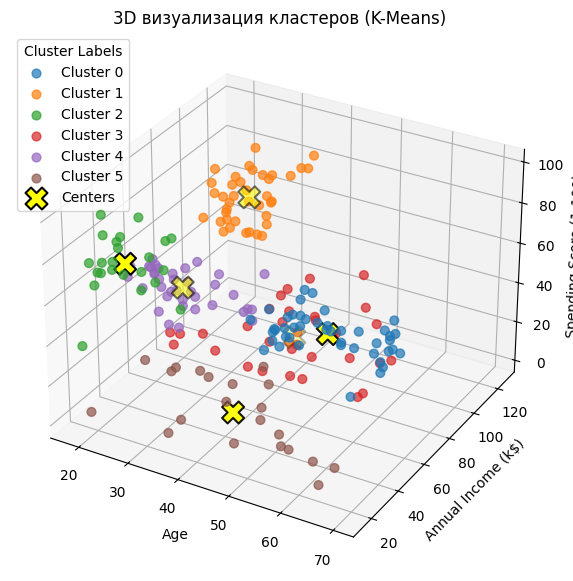

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

clusters = sorted(df["Cluster"].unique())
colors = plt.cm.tab10(range(len(clusters)))


for cluster_id, color in zip(clusters, colors):
    cluster_data = df[df["Cluster"] == cluster_id]
    ax.scatter(
        cluster_data["Age"],
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        s=40,
        alpha=0.7,
        color=color,
        label=f"Cluster {cluster_id}"
    )


ax.scatter(
    centers[:, 0],   # Age
    centers[:, 1],   # Annual Income
    centers[:, 2],   # Spending Score
    marker="X",
    s=250,
    color="yellow",
    edgecolor="black",
    linewidth=1.5,
    label="Centers"
)


ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")

ax.set_title("3D визуализация кластеров (K-Means)")


ax.legend(
    title="Cluster Labels",
    loc="upper left"
)

plt.show()

Визуально, по признаку Age покупатели делятся примерно на 2 группы: старше 25 лет и младше. Причем, у второй группы заметно выше активность. В тоже время, у более возрастной группы зачастую более высокие траты. При этом внутри каждой возрастной группы наблюдается дополнительная сегментация по уровню дохода и потребительскому поведению. Среди клиентов младше 25 лет можно выделить подгруппы как с высоким, так и с умеренным уровнем дохода, однако для большинства из них характерен высокий показатель Spending Score, что свидетельствует о большей склонности к активным, импульсивным покупкам. 
Для покупателей старше 25 лет характерна более разнородная структура. В этой группе присутствуют клиенты с высоким годовым доходом, но умеренной или низкой потребительской активностью, что может указывать на более рациональный и взвешенный подход к расходам. Одновременно с этим выделяется сегмент клиентов среднего и старшего возраста с высокими доходами и высокими тратами.
Таким образом, возраст выступает важным фактором первичного разделения клиентов, однако окончательная структура кластеров формируется за счёт сочетания возрастных характеристик с уровнем дохода и показателем потребительской активности. 
